# FoodLens — Nəticələr / Results

Bu notebook `reports/` qovluğundakı bütün qrafikləri və metrikaları slaydlar üçün bir yerə yığır.

This notebook assembles every chart and metric from `reports/` for the slides. Run top-to-bottom after `python -m src.cnn.evaluate --gradcam 10` and `python -m src.cv.validate_portion`.

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

REPORTS = Path('..') / 'reports'

def show(path, title=None, w=11):
    img = mpimg.imread(str(REPORTS / path))
    h = w * img.shape[0] / img.shape[1]
    plt.figure(figsize=(w, h))
    plt.imshow(img); plt.axis('off')
    if title: plt.title(title)
    plt.show()

## 1. Model müqayisəsi / Model comparison (test set)

In [2]:
metrics = json.load(open(REPORTS / 'metrics.json', encoding='utf-8'))
print(f"{'model':<10}{'top1':>8}{'top5':>8}{'macroF1':>9}{'params':>12}{'cpu ms':>8}")
for n, m in metrics.items():
    print(f"{n:<10}{m['top1_acc']:>8.3f}{m['top5_acc']:>8.3f}"
          f"{m['macro_f1']:>9.3f}{m['params']:>12,}{m['cpu_ms_per_image']:>8.1f}")

model         top1    top5  macroF1      params  cpu ms
simple       0.504   0.843    0.486     395,801    11.8
effnet       0.923   0.989    0.922   4,039,573    21.9


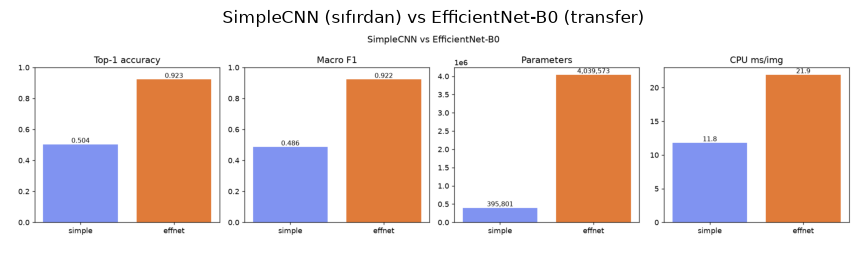

In [3]:
show('model_comparison.png', 'SimpleCNN (sıfırdan) vs EfficientNet-B0 (transfer)')

## 2. Öyrənmə əyriləri / Training curves

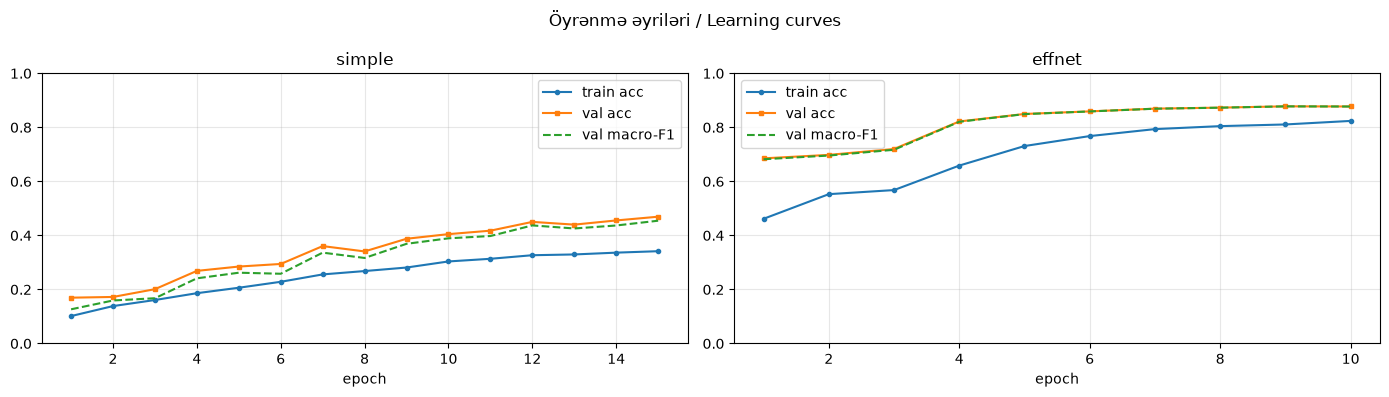

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, name in zip(axes, ['simple', 'effnet']):
    hist = json.load(open(REPORTS / f'history_{name}.json', encoding='utf-8'))
    ep = [h['epoch'] for h in hist]
    ax.plot(ep, [h['train_acc'] for h in hist], label='train acc', marker='o', ms=3)
    ax.plot(ep, [h['val_acc'] for h in hist], label='val acc', marker='s', ms=3)
    ax.plot(ep, [h['val_macro_f1'] for h in hist], label='val macro-F1', ls='--')
    ax.set_title(name); ax.set_xlabel('epoch'); ax.set_ylim(0, 1); ax.legend(); ax.grid(alpha=.3)
fig.suptitle('Öyrənmə əyriləri / Learning curves'); fig.tight_layout(); plt.show()

## 3. Confusion matrisləri / Confusion matrices

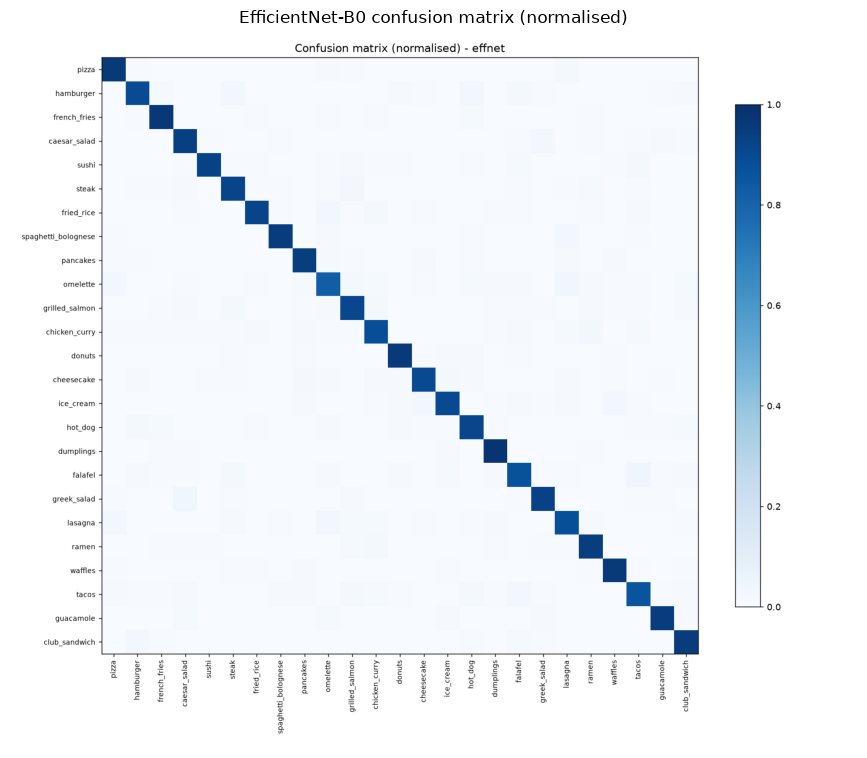

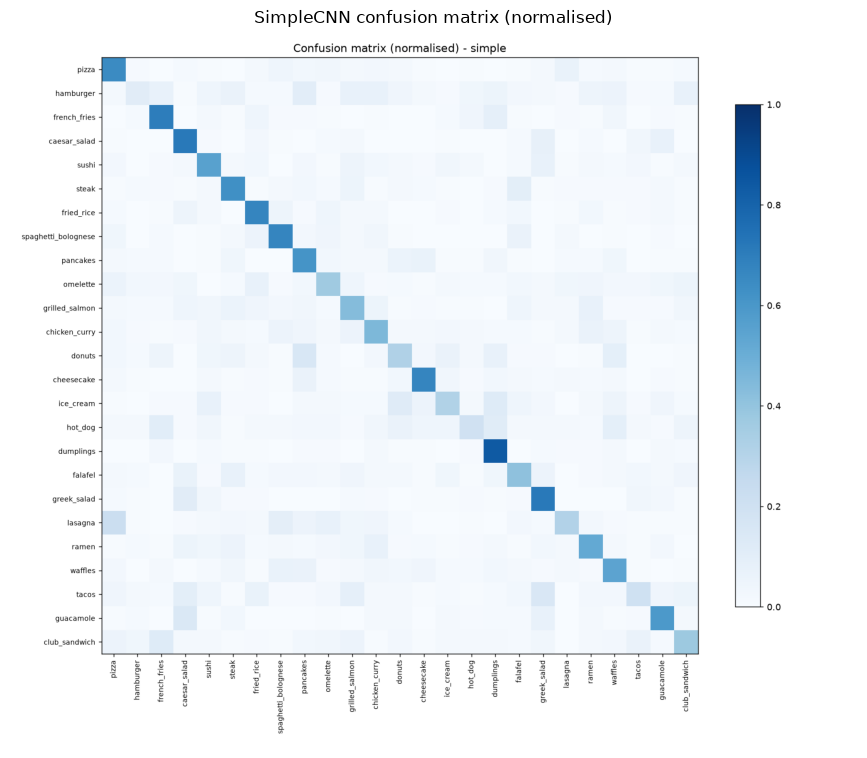

In [5]:
show('confusion_matrix_effnet.png', 'EfficientNet-B0 confusion matrix (normalised)')
show('confusion_matrix_simple.png', 'SimpleCNN confusion matrix (normalised)')

## 4. Sinif üzrə F1 / Per-class F1 (ən zəif siniflər aşağıda)

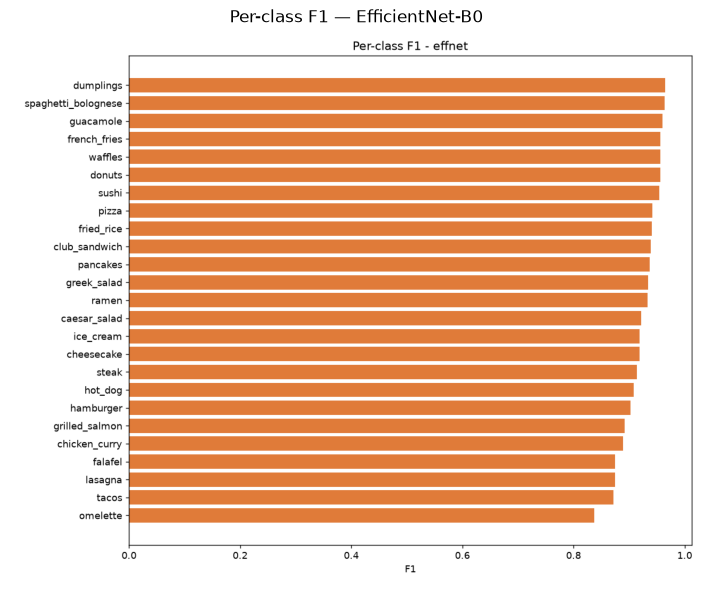

In [6]:
show('per_class_f1_effnet.png', 'Per-class F1 — EfficientNet-B0', w=9)

## 5. Grad-CAM — model nəyə baxır? / What is the model looking at?

`WRONG` = səhv təsnifat (interpretasiya üçün ən dəyərlisi).

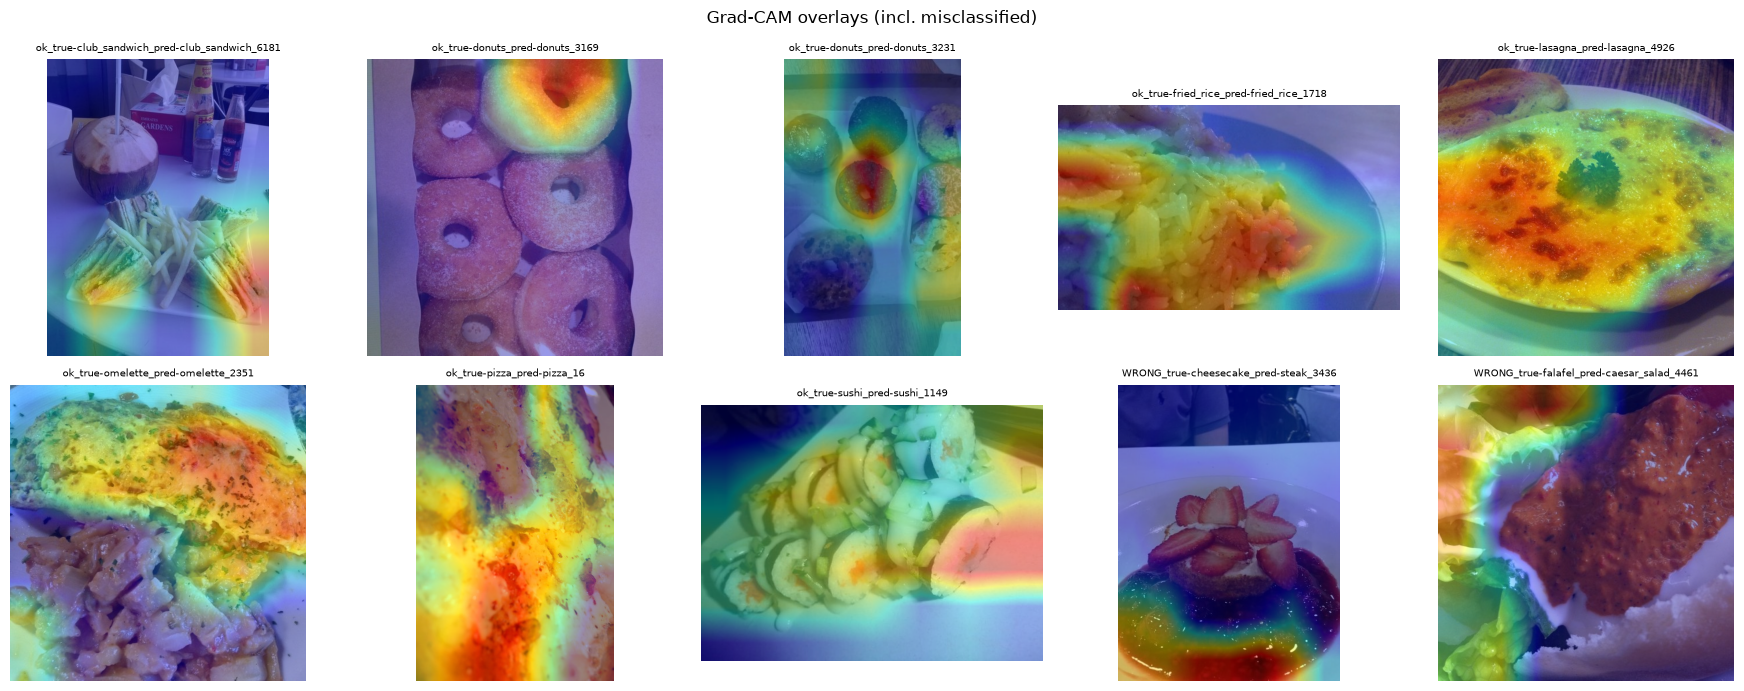

In [7]:
gc = sorted((REPORTS / 'gradcam').glob('*.png'))
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, p in zip(axes.ravel(), gc):
    ax.imshow(mpimg.imread(str(p))[:, :, ::-1] if False else mpimg.imread(str(p)))
    ax.set_title(p.stem.replace('effnet_', ''), fontsize=7)
    ax.axis('off')
for ax in axes.ravel()[len(gc):]:
    ax.axis('off')
fig.suptitle('Grad-CAM overlays (incl. misclassified)'); fig.tight_layout(); plt.show()

## 6. Porsiya validasiyası / Portion validation

**Diqqət:** Food-101-də çəkilmiş həqiqi kütlə yoxdur; `reference_g` nominal porsiyadır. Xəta agreement-with-nominal ölçür, fiziki xəta deyil (bax `reports/portion_validation.md`).

MAE = 158.7 g   MAPE = 131.2 %   median APE = 78.1 %
no plate detected: 1/12


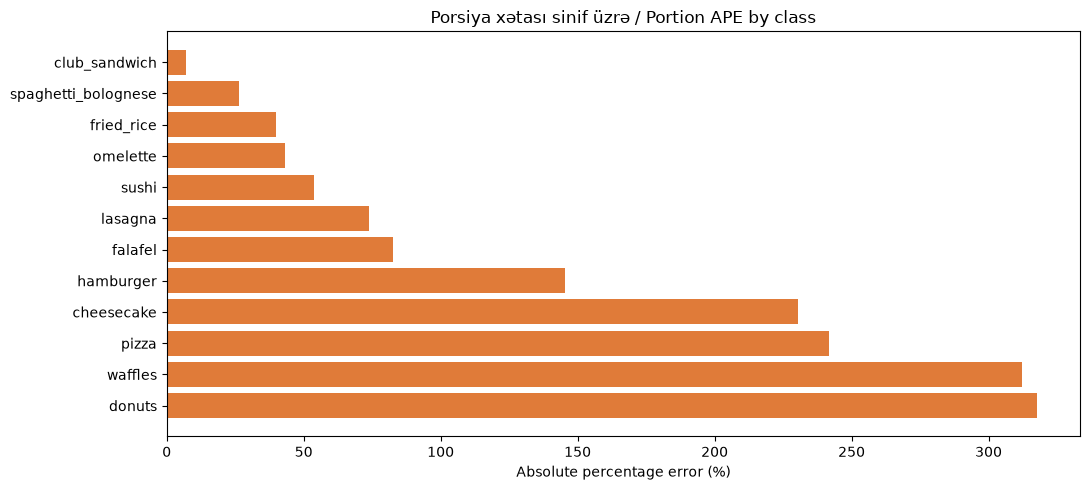

In [8]:
pv = json.load(open(REPORTS / 'portion_validation.json', encoding='utf-8'))
print(f"MAE = {pv['mae_g']} g   MAPE = {pv['mape_pct']} %   median APE = {pv['median_ape_pct']} %")
print(f"no plate detected: {pv['no_plate_count']}/{pv['n']}")
rows = sorted(pv['rows'], key=lambda r: r['ape_pct'])
fig, ax = plt.subplots(figsize=(11, 5))
ax.barh([r['class'] for r in rows], [r['ape_pct'] for r in rows], color='#e07b39')
ax.set_xlabel('Absolute percentage error (%)'); ax.set_title('Porsiya xətası sinif üzrə / Portion APE by class')
ax.invert_yaxis(); fig.tight_layout(); plt.show()